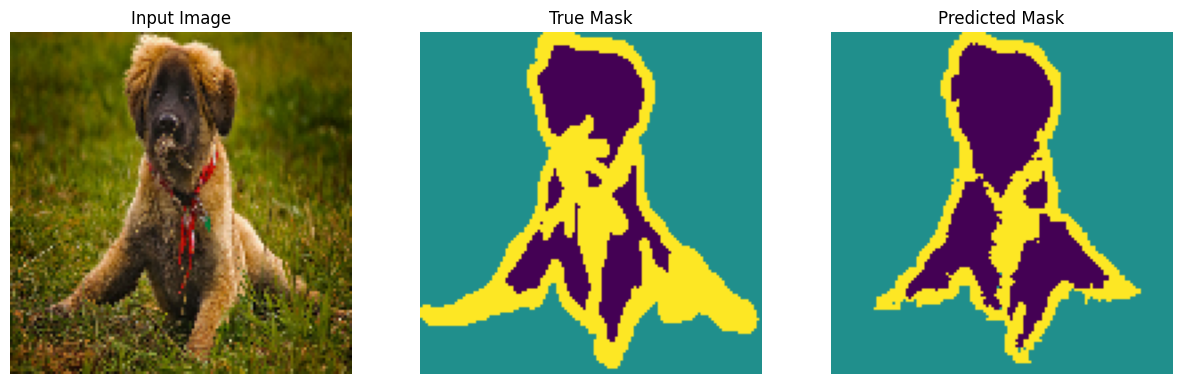


Sample Prediction after epoch 5

115/115 ━━━━━━━━━━━━━━━━━━━━ 406s 4s/step - accuracy: 0.9029 - loss: 0.2475 - val_accuracy: 0.8992 - val_loss: 0.2689


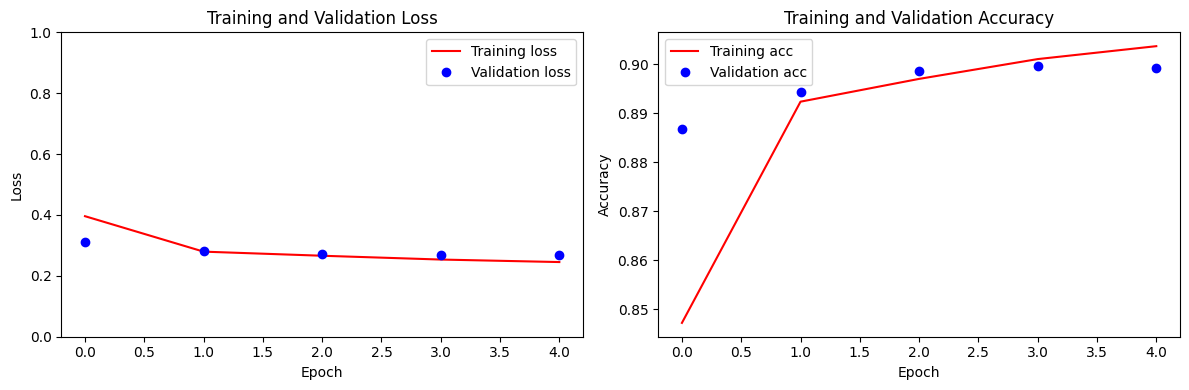

In [ ]:
# ==============================
# 0. Импорты
# ==============================
import tensorflow as tf
import tensorflow_datasets as tfds
from IPython.display import clear_output
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# ==============================
# 1. Загрузка и предобработка данных
# ==============================
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 32  # можно 16, 32, 64 — в зависимости от памяти
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1  # маска: -1 (фон), 0 (животное), 1 (контур)
    return input_image, input_mask

def load_image(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(
        datapoint['segmentation_mask'],
        (128, 128),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

# ==============================
# 2. Аугментация
# ==============================
class Augment(tf.keras.layers.Layer):
    def __init__(self, seed=42):
        super().__init__()
        self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
        self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels

train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_batches = test_images.batch(BATCH_SIZE)

# ==============================
# 3. Визуализация
# ==============================
def display(display_list):
    plt.figure(figsize=(15, 5))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

# Проверка загрузки
for images, masks in train_batches.take(1):
    sample_image, sample_mask = images[0], masks[0]
    break

display([sample_image, sample_mask, sample_mask])  # placeholder

# ==============================
# 4. Энкодер: MobileNetV2 (как в методичке)
# ==============================
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]

base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False  # ← заморожено для базовой модели

# ==============================
# 5. Декодер: upsample (с опциональным Dropout)
# ==============================
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(
            filters, size, strides=2,
            padding='same',
            kernel_initializer=initializer,
            use_bias=False
        )
    )
    result.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))
    result.add(tf.keras.layers.ReLU())
    return result

# Базовый декодер (без Dropout, как в методичке)
up_stack = [
    upsample(512, 3),
    upsample(256, 3),
    upsample(128, 3),
    upsample(64,  3),
]

# ==============================
# 6. U-Net модель
# ==============================
def unet_model(output_channels: int, apply_dropout=False):
    # Пересоздаём up_stack с нужным apply_dropout
    local_up_stack = [
        upsample(512, 3, apply_dropout=apply_dropout),
        upsample(256, 3, apply_dropout=apply_dropout),
        upsample(128, 3, apply_dropout=apply_dropout),
        upsample(64,  3, apply_dropout=apply_dropout),
    ]

    inputs = tf.keras.layers.Input(shape=[128, 128, 3])
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    for up, skip in zip(local_up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2, padding='same'  # 64→128
    )
    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

# ==============================
# 7. Исправленный DisplayCallback (БЕЗ ошибки!)
# ==============================
class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, num_samples=1):
        super().__init__()
        self.dataset = dataset
        self.num_samples = num_samples

    def on_epoch_end(self, epoch, logs=None):
        # ✅ self.model доступен автоматически после model.fit()
        clear_output(wait=True)
        self.show_predictions()
        print(f'\nSample Prediction after epoch {epoch + 1}\n')

    def show_predictions(self):
        for image_batch, mask_batch in self.dataset.take(1):
            pred_mask_batch = self.model.predict(image_batch, verbose=0)
            image = image_batch[0]
            mask = mask_batch[0]
            pred_mask = self.create_mask(pred_mask_batch[0])
            display([image, mask, pred_mask])
            break

    def create_mask(self, pred_mask):
        pred_mask = tf.math.argmax(pred_mask, axis=-1)
        pred_mask = pred_mask[..., tf.newaxis]
        return pred_mask

# ==============================
# 8. Базовая модель (как в методичке)
# ==============================
OUTPUT_CLASSES = 3

model = unet_model(output_channels=OUTPUT_CLASSES, apply_dropout=False)
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Визуализация графа модели (опционально — может не работать в Colab без graphviz)
# tf.keras.utils.plot_model(model, show_shapes=True)

# ==============================
# 9. Обучение
# ==============================
EPOCHS = 5  # ↓ уменьшено для быстрой проверки (можно 10–20)
VAL_SUBSPLITS = 5
VALIDATION_STEPS = info.splits['test'].num_examples // BATCH_SIZE // VAL_SUBSPLITS

print("🚀 Начинаем обучение базовой модели...")
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_batches,
    validation_steps=VALIDATION_STEPS,
    callbacks=[DisplayCallback(train_batches)],  # ← исправлено!
    verbose=1
)

# ==============================
# 10. Графики обучения
# ==============================
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(loss))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'r', label='Training loss')
plt.plot(epochs_range, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'r', label='Training acc')
plt.plot(epochs_range, val_acc, 'bo', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()